### Strategy 1st try 

Investment horizon : 5 days 

Strategy 1: 
Compare predicted volatility to avg. volatility 
Open Butterfly long if pred_vol < avg_vol

Strategy 2: 
Compare predicted volatility to implied volatility
Open Butterfly long if pred_vol < IV





In [14]:
# %pip install py_vollib

In [15]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from py_vollib.black_scholes import black_scholes
from scipy.stats import percentileofscore
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import yfinance as yf
from py_vollib.black_scholes import implied_volatility
import datetime as dt
import pytz

#### Data import 

data requirements: 

options_data = options_data # DataFrame with columns: timestamp, expiration_date, strike_price, type, opt_close, dtm, SPY_close, volume, open_interest


underlying_data = underlying_data # DataFrame with columns: timestamp, close, volume

vol_predictions = vol_predictions # DataFrame with columns: prediction_day, predicted_day, predicted_vol

In [16]:
# load data 

underlying_data= pd.read_csv(r"C:\Users\pauli\Butterflies-\yfinance_data\spy.csv")

vol_predictions = pd.read_csv(r"C:\Users\pauli\Butterflies-\model\predictions\slightlybetter.csv")

options_data = pd.read_csv(r"C:\Users\pauli\Butterflies-\options\options.csv")

In [17]:
# Underlying data
underlying_data = underlying_data.iloc[2:]
underlying_data = underlying_data.rename(columns={'Price' : 'timestamp', 'Close' : 'close', 'Volume' : 'volume'})

# fix datetime and UTC issues 
underlying_data['timestamp'] = pd.to_datetime(underlying_data['timestamp'])
underlying_data['timestamp'] = underlying_data['timestamp'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

# Numeric values
underlying_data['close'] = pd.to_numeric(underlying_data['close'], errors='coerce')
underlying_data['volume'] = pd.to_numeric(underlying_data['volume'], errors='coerce')


In [18]:
options_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142540 entries, 0 to 142539
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      142540 non-null  int64  
 1   symbol                          142540 non-null  object 
 2   date                            142540 non-null  object 
 3   opt_close                       142540 non-null  float64
 4   volume                          142540 non-null  float64
 5   trade_count                     142540 non-null  float64
 6   vwap                            142540 non-null  float64
 7   expiration_date                 142540 non-null  object 
 8   strike_price                    142540 non-null  float64
 9   size                            142540 non-null  int64  
 10  type                            142540 non-null  object 
 11  style                           142540 non-null  object 
 12  open_interest   

In [19]:
# Options data
options_data= options_data.rename(columns={'close' : 'opt_close', 'date': "timestamp", 'close_price' : 'close_price_on_expiry'}) 
options_data['expiration_date'] = pd.to_datetime(options_data['expiration_date'])
options_data['timestamp'] = pd.to_datetime(options_data['timestamp'])
options_data["open_interest_date"] = pd.to_datetime(options_data["open_interest_date"])
options_data["close_price_date"] = pd.to_datetime(options_data["close_price_date"])


# add UTC to timestamps 

options_data["timestamp"] = options_data["timestamp"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data['expiration_date'] = options_data['expiration_date'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data["close_price_date"] = options_data["close_price_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data["open_interest_date"] = options_data["open_interest_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

# calculate dtm 
options_data['dtm'] = options_data.apply(
    lambda row: np.busday_count(row['timestamp'].date(), row['expiration_date'].date()),
    axis=1
)    #trading_days_to_expiry


# Numeric values 
options_data['opt_close'] = pd.to_numeric(options_data['opt_close'], errors='coerce')
options_data['open_interest'] = pd.to_numeric(options_data['open_interest'], errors='coerce')
options_data['volume'] = pd.to_numeric(options_data['volume'], errors='coerce')
options_data['strike_price'] = pd.to_numeric(options_data['strike_price'], errors='coerce')


In [20]:
# for day in options_data['timestamp'].dt.date.unique():
#     expiry_candidates = options_data[
#                         (options_data['timestamp'].dt.date == day) & (options_data['dtm'] == 5)
#                     ]['expiration_date'].unique()
#     print(f"Expiry candidates for {day}: {expiry_candidates}")

options_data_ana = options_data[["timestamp", "symbol", "expiration_date", "strike_price", "opt_close", "dtm"]]
options_data_ana[(options_data_ana['timestamp'] == "2024-03-05 05:00:00+00:00")].sort_values(by="expiration_date", ascending=True).tail(20)
options_data_ana[(options_data_ana['symbol'] == "SPY240312P00475000")].sort_values(by="timestamp", ascending=True)

,timestamp,symbol,expiration_date,strike_price,opt_close,dtm
1358,2024-03-05 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.13,5
1359,2024-03-06 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.06,4
1360,2024-03-07 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.04,3
1361,2024-03-08 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.03,2
1362,2024-03-11 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.01,1


In [21]:
# Vola predictions adjustments
# columns to numeric values


vol_predictions["prediction_day"] = pd.to_datetime(vol_predictions['prediction_day'])
vol_predictions["predicted_day"] = pd.to_datetime(vol_predictions['predicted_day'])

#fix utc issues 


vol_predictions["prediction_day"] = vol_predictions["prediction_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
vol_predictions["predicted_day"] = vol_predictions["predicted_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

vol_predictions["prediction_day"] = vol_predictions["prediction_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
vol_predictions["predicted_day"] = vol_predictions["predicted_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)


vol_predictions = vol_predictions.rename(columns={'predicted_vola': 'predicted_vol'})
vol_predictions['predicted_vol'] = pd.to_numeric(vol_predictions['predicted_vol'], errors='coerce')


In [22]:
vol_predictions
#options_data
#underlying_data

,Unnamed: 0,predicted_vol,prediction_day,predicted_day
0,0,0.118044,2024-04-30 05:00:00+00:00,2024-05-07 05:00:00+00:00
1,1,0.130076,2024-05-01 05:00:00+00:00,2024-05-08 05:00:00+00:00
2,2,0.142582,2024-05-02 05:00:00+00:00,2024-05-09 05:00:00+00:00
3,3,0.137289,2024-05-03 05:00:00+00:00,2024-05-10 05:00:00+00:00
4,4,0.131275,2024-05-06 05:00:00+00:00,2024-05-13 05:00:00+00:00
...,...,...,...,...
268,268,0.172218,2025-05-27 05:00:00+00:00,2025-06-03 05:00:00+00:00
269,269,0.161772,2025-05-28 05:00:00+00:00,2025-06-04 05:00:00+00:00
270,270,0.157839,2025-05-29 05:00:00+00:00,2025-06-05 05:00:00+00:00
271,271,0.156251,2025-05-30 05:00:00+00:00,2025-06-06 05:00:00+00:00


In [23]:
# filter timestamps for all dataframes based on the available options 

# start_time = '2024-04-01 05:00:00+00:00'
# end_time = '2024-06-01 05:00:00+00:00'
# options_data =  options_data[(options_data['timestamp'] >= start_time) & (options_data['timestamp'] <= end_time)]

start_date = options_data['timestamp'].min()
end_date = options_data['timestamp'].max()



vol_predictions = vol_predictions[(vol_predictions['prediction_day'] >= start_date) & (vol_predictions['prediction_day'] <= end_date)]
underlying_data = underlying_data[(underlying_data['timestamp'] >= start_date) & (underlying_data['timestamp'] <= end_date)]
underlying_data = underlying_data[(underlying_data['timestamp'] <= end_date)]

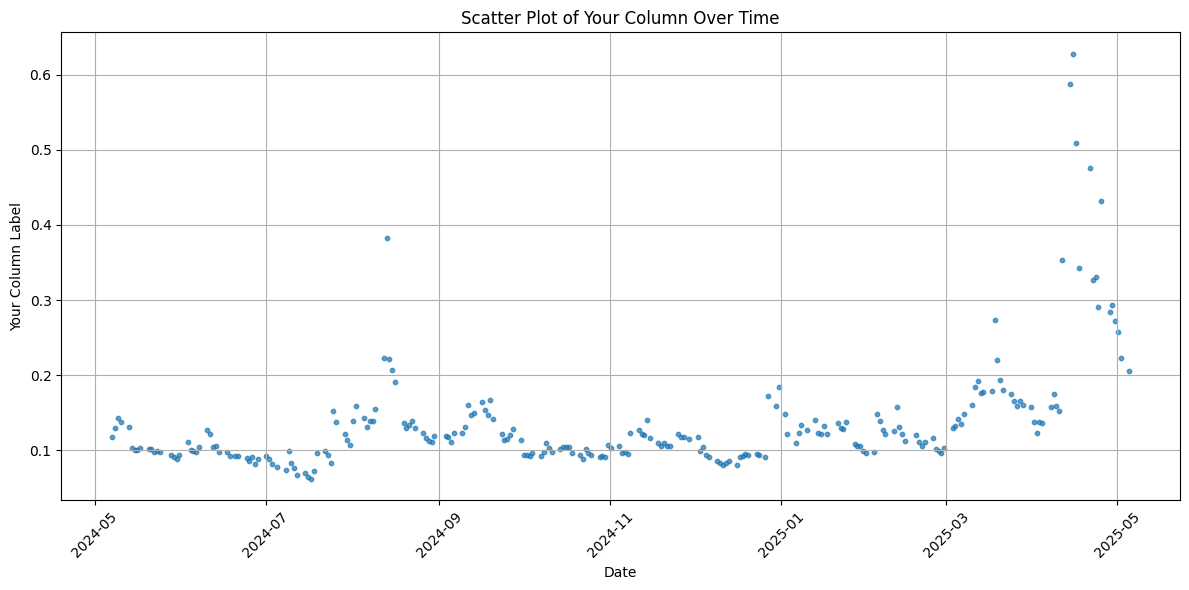

In [24]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(vol_predictions['predicted_day'], vol_predictions['predicted_vol'], s=10, alpha=0.7)
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Your Column Label')
plt.title('Scatter Plot of Your Column Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# from Butterfly_long_backtest import ButterflyBacktest



# # Make sure your DataFrames are loaded and preprocessed:
# # options_data, underlying_data, vol_predictions

# # Instantiate the backtest class
# bt = ButterflyBacktest(
#     options_data=options_data,
#     underlying_data=underlying_data,
#     vol_predictions=vol_predictions,  
#     spread_pct=1,                     # pct of the underlying price to set the spread width
#     commission=1.0,                   # teke into account commission costs
#     slippage=0.01,                    # take into account slippage
#     min_open_interest=0,             # ensure sufficient open interest
#     min_volume=1,                     # ensure sufficient liquidity
#     vol_exit_threshold=10            # exit if the predicted volatility changes by more than this percentage
# )

# # Run the backtest
# results_df, equity_df = bt.run(option_type='call', starting_cash=1000)

# # Display results
# print(results_df.head())
# print(equity_df.head())

In [26]:
options_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142540 entries, 0 to 142539
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype              
---  ------                          --------------   -----              
 0   Unnamed: 0                      142540 non-null  int64              
 1   symbol                          142540 non-null  object             
 2   timestamp                       142540 non-null  datetime64[ns, UTC]
 3   opt_close                       142540 non-null  float64            
 4   volume                          142540 non-null  float64            
 5   trade_count                     142540 non-null  float64            
 6   vwap                            142540 non-null  float64            
 7   expiration_date                 142540 non-null  datetime64[ns, UTC]
 8   strike_price                    142540 non-null  float64            
 9   size                            142540 non-null  int64              
 

Total dates to process: 290
Processing day: 2024-03-01
No prediction for 2024-03-01
Processing day: 2024-03-04
No prediction for 2024-03-04
Processing day: 2024-03-05
No prediction for 2024-03-05
Processing day: 2024-03-06
No prediction for 2024-03-06
Processing day: 2024-03-07
No prediction for 2024-03-07
Processing day: 2024-03-08
No prediction for 2024-03-08
Processing day: 2024-03-11
No prediction for 2024-03-11
Processing day: 2024-03-12
No prediction for 2024-03-12
Processing day: 2024-03-13
No prediction for 2024-03-13
Processing day: 2024-03-14
No prediction for 2024-03-14
Processing day: 2024-03-15
No prediction for 2024-03-15
Processing day: 2024-03-18
No prediction for 2024-03-18
Processing day: 2024-03-19
No prediction for 2024-03-19
Processing day: 2024-03-20
No prediction for 2024-03-20
Processing day: 2024-03-21
No prediction for 2024-03-21
Processing day: 2024-03-22
Processing day: 2024-03-25
No prediction for 2024-03-25
Processing day: 2024-03-26
No prediction for 2024

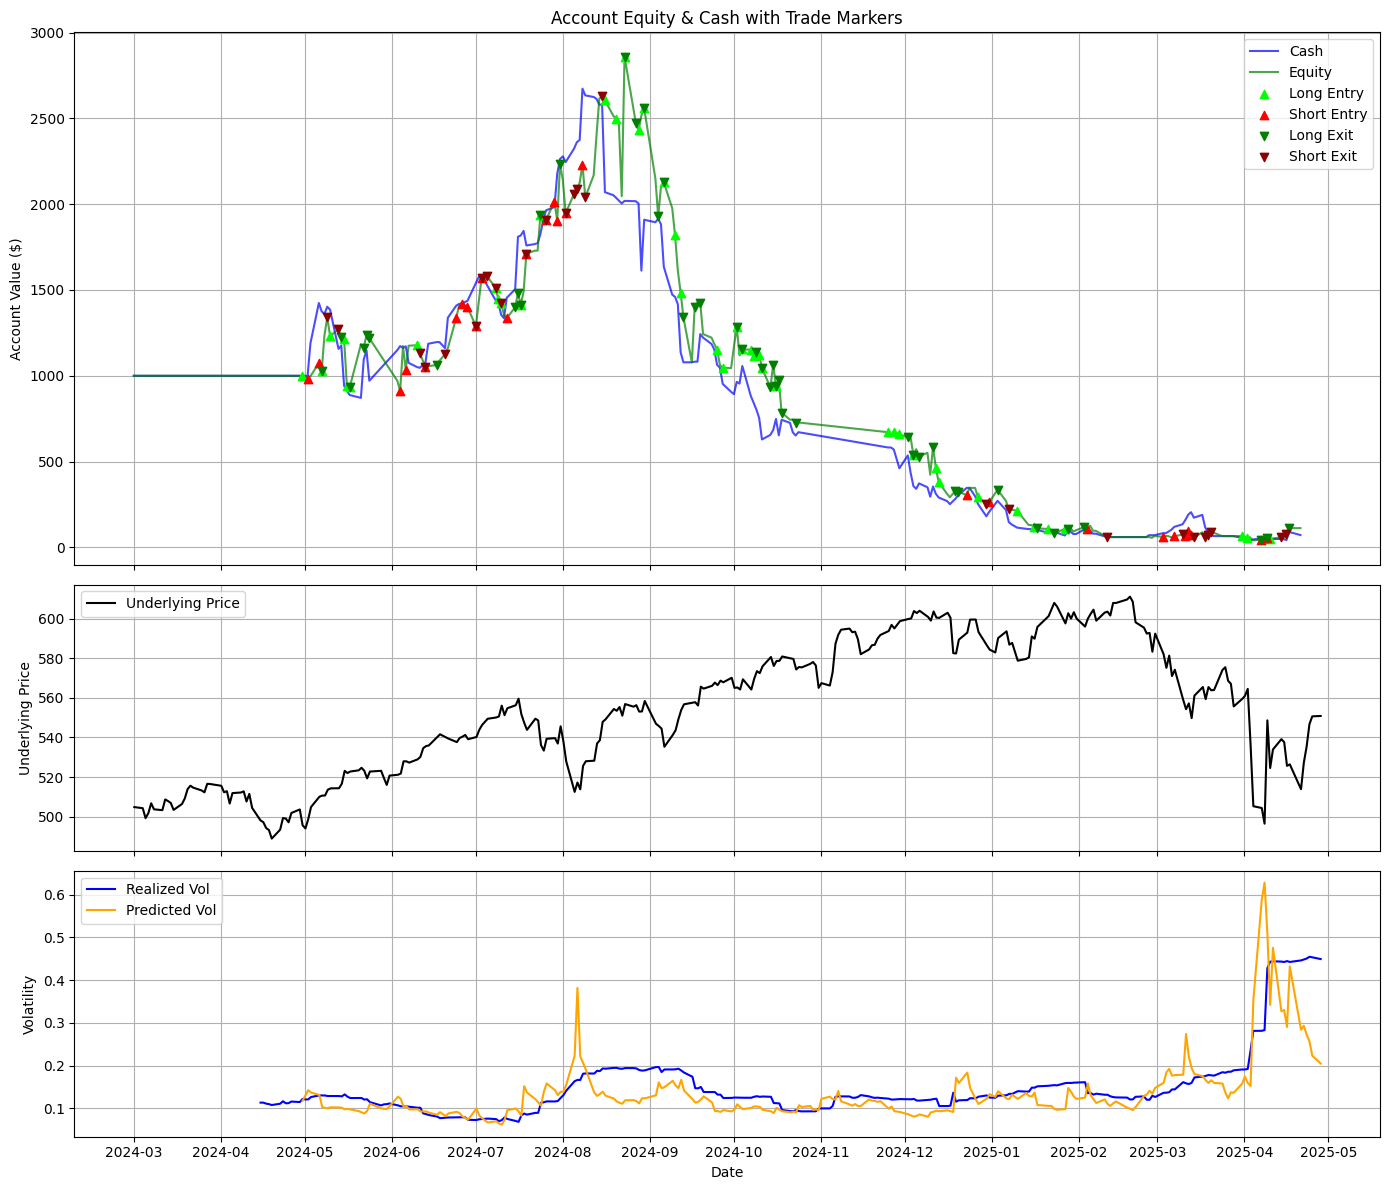

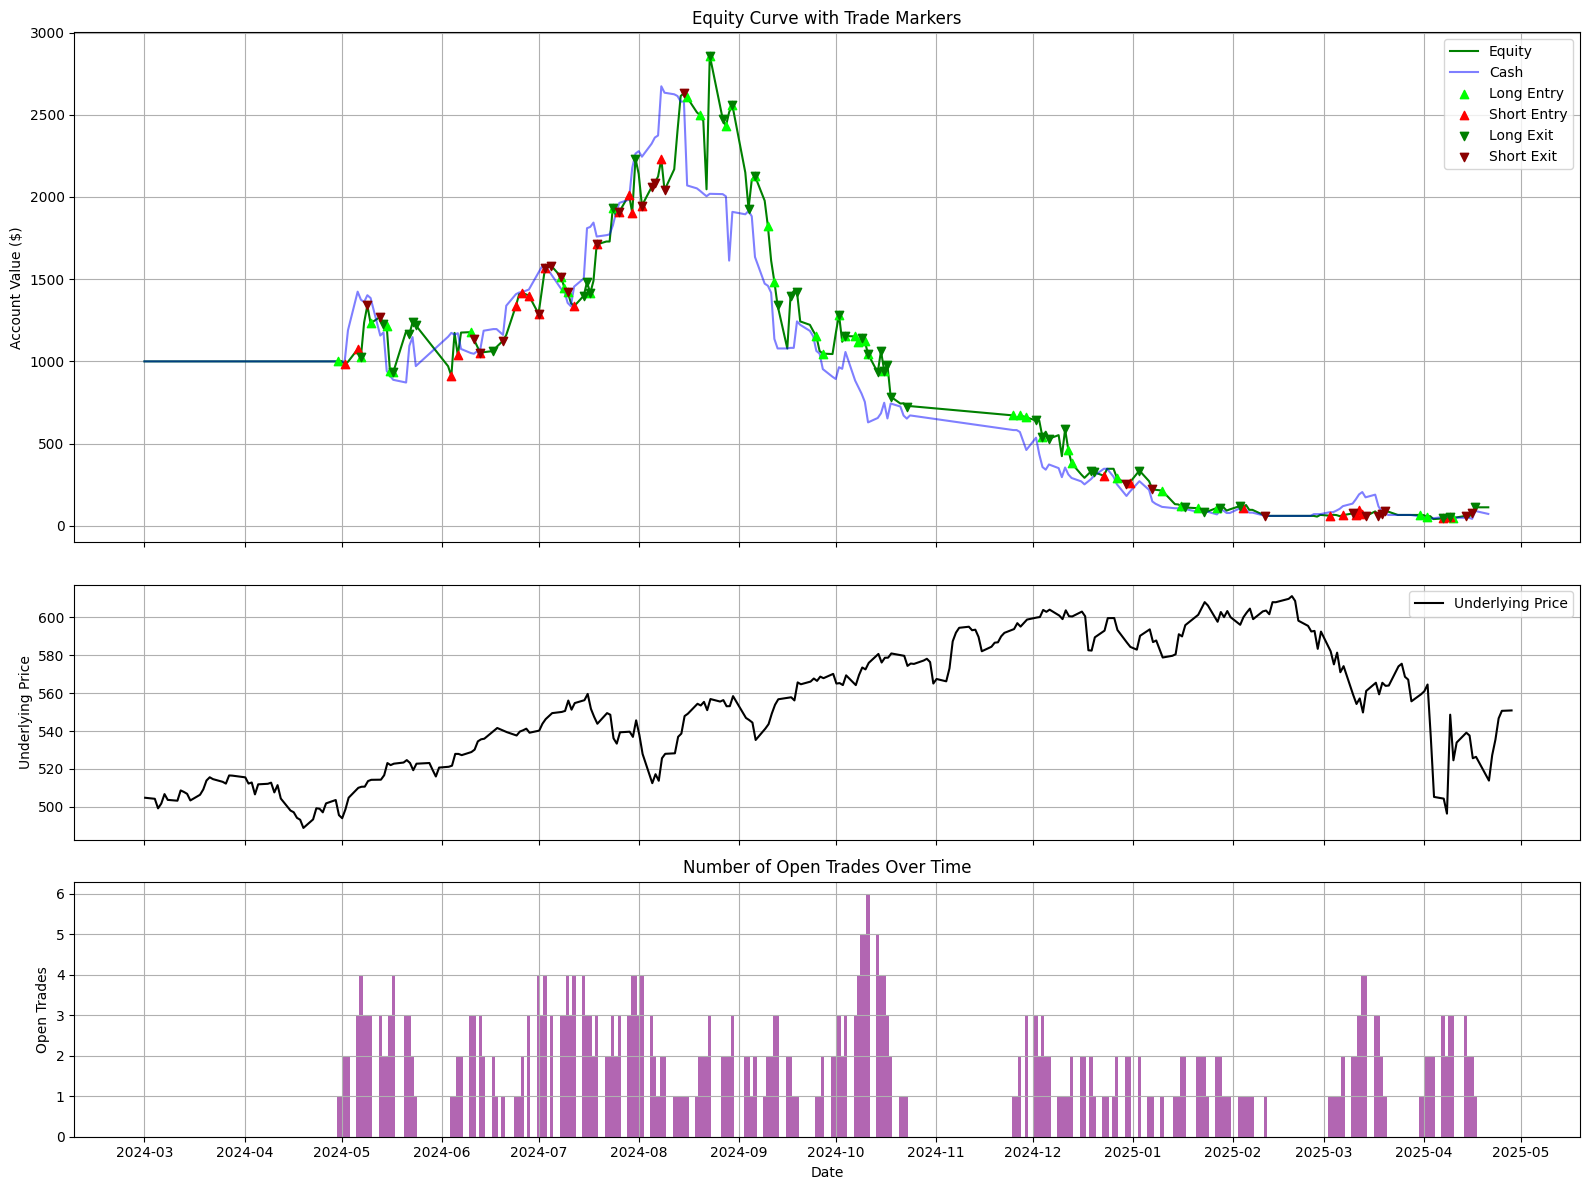

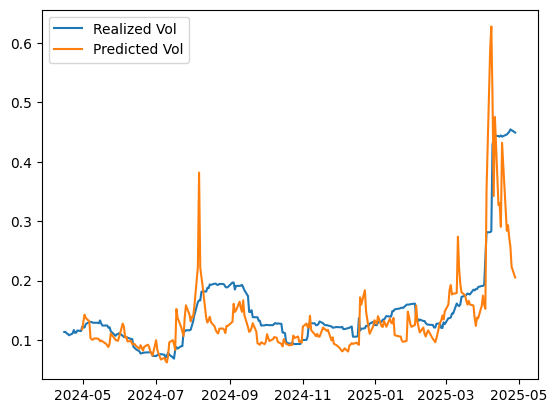

   entry_date   exit_date                    expiry  entry_price  exit_price  \
0  2024-04-30  2024-05-07 2024-05-07 05:00:00+00:00         3.28      -10.01   
1  2024-05-02  2024-05-09 2024-05-09 05:00:00+00:00        -0.87        7.50   
2  2024-05-06  2024-05-13 2024-05-13 05:00:00+00:00        -9.83       -8.83   
3  2024-05-07  2024-05-14 2024-05-14 05:00:00+00:00        12.78        6.37   
4  2024-05-10  2024-05-17 2024-05-17 05:00:00+00:00        17.02        9.84   

   n_butterflies    pnl  underlying_price_entry  underlying_price_exit  \
0              1 -13.33              495.671356             510.640839   
1             10  83.30              498.682983             513.632690   
2             24  23.04              510.078033             514.363403   
3              3 -19.35              510.640839             516.723389   
4              1  -7.22              514.294373             522.796082   

                 strikes  option_prices_entry    option_prices_exit  \
0  

In [ ]:
from Butterfly_long_and_short_backtest import ButterflyBacktest_long_short


# Make sure your DataFrames are loaded and preprocessed:
# options_data, underlying_data, vol_predictions




# Instantiate the backtest class
bt_sl = ButterflyBacktest_long_short(
    options_data = options_data, 
    underlying_data = underlying_data, 
    vol_predictions = vol_predictions, 
    spread_pct=6,                                # Tune 
    commission=0.01, 
    slippage=0.0, 
    min_open_interest=0, 
    min_volume=0, 
    vol_exit_threshold=50, # exit if the predicted volatility changes by more than this percentage, TUNE
    rolling_window=30
    pct_above= 0.5, # TUNE, percentage above the predicted volatility to enter a short
    pct_below= 0.5, # TUNE, percentage below the predicted volatility to enter a long
) 



# Run the backtest
results_df, equity_df = bt_sl.run(option_type='call', starting_cash=1000, risk_free_rate=0.045)

# Display results
print(results_df.head())
print(equity_df.head())



In [15]:
results_df#equity_df
underlying_data

,timestamp,close,High,Low,Open,volume,realized_vol,date
5076,2024-03-01 05:00:00+00:00,504.836182,505.26930860368725,500.6132388118338,501.0266891095606,76805900,NaN,2024-03-01
5077,2024-03-04 05:00:00+00:00,504.294800,506.16513448035585,503.9994996141668,504.02905967393,49799300,NaN,2024-03-04
5078,2024-03-05 05:00:00+00:00,499.254761,502.71977618889395,497.02024274409166,502.26694255347593,72855600,NaN,2024-03-05
5079,2024-03-06 05:00:00+00:00,501.784607,504.06836164328706,500.4754028347389,502.57209405521513,68382400,NaN,2024-03-06
5080,2024-03-07 05:00:00+00:00,506.765564,507.8287046812671,501.8436940869461,505.12167624842334,58652100,NaN,2024-03-07
...,...,...,...,...,...,...,...,...
5361,2025-04-22 05:00:00+00:00,527.250000,529.2999877929688,519.1900024414062,520.1400146484375,75948100,0.286460,2025-04-22
5362,2025-04-23 05:00:00+00:00,535.419983,545.4299926757812,533.8800048828125,540.4299926757812,90590700,0.287814,2025-04-23
5363,2025-04-24 05:00:00+00:00,546.690002,547.4299926757812,535.4500122070312,536.719970703125,64150400,0.289825,2025-04-24
5364,2025-04-25 05:00:00+00:00,550.640015,551.0499877929688,543.6900024414062,546.6500244140625,61119600,0.290055,2025-04-25


In [18]:
equity_df.tail(10)

,date,cash,equity,margin_available,total_max_loss
240,2025-04-04,1249.33,1331.12,1160.1685,0
241,2025-04-07,1408.66,1349.68,1186.8635,0
242,2025-04-08,1428.71,1250.91,1338.2270,0
243,2025-04-09,1668.56,1248.31,1357.2745,0
244,2025-04-10,1816.81,1079.23,1585.1320,0
245,2025-04-14,2016.27,728.32,1725.9695,0
246,2025-04-15,2032.00,781.72,1915.4565,0
247,2025-04-16,1824.95,1252.31,1930.4000,0
248,2025-04-17,1272.92,1005.49,1733.7025,0
249,2025-04-21,1263.70,1187.19,1209.2740,0


## model tryout

In [13]:

%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [14]:
import tensorflow as tf

ImportError: Traceback (most recent call last):
  File "c:\Users\pauli\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [ ]:
loaded_model = tf.keras.models.load_model(r"C:\Users\pauli\Butterflies-\model\models\model1.h5")

NameError: name 'tf' is not defined

## Visualization Tools

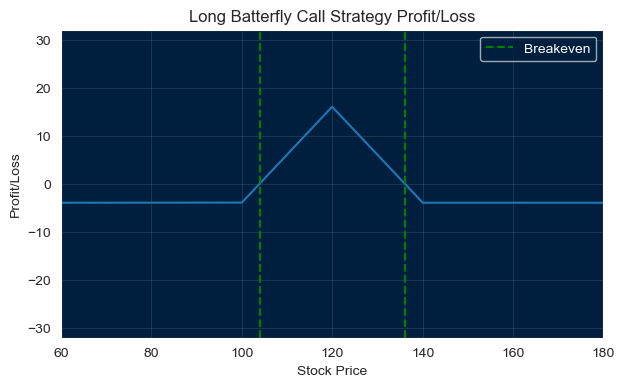

Net Cost/Credit: -3.9593731000237256
Profit if price will be between 103.95844395844395 and 136.04155604155605
Loss if price will be lower than 103.95844395844395 or higher than 136.04155604155605


In [ ]:
#------------------------------------------------
# # play with option strategy 
#-----------------------------------------------
from OptionStrategyfunctions import OptionStrategy

# OptionStrategy(Price_underlying,risk_free_rate = , days_to_maturity)


option = OptionStrategy(80,0.1,2)
sigma = 0.189 # adapt as dynamic rolling window (90 days?) 

option.long_butterfly_call(sigma, 100, 120, 140)

